# Validation: Does the pattern hold up when stratifying across different lighting conditions? Do we see very different lighting between west and east?

**Purpose**: Use the manually binned data from coauthors S.H.C. and R.H. to examine the affect of lighting category on color inference between regions.  
  
This notebook contains the MANOVA, ANOVA's, and panels for **Figure 3EF**.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import cv2
from scipy.stats import chi2_contingency
from sklearn.metrics import cohen_kappa_score

# anova stuff
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.multivariate.manova import MANOVA

# for converting cielab to LCh
from colormath.color_objects import LabColor, LCHabColor
from colormath.color_conversions import convert_color

In [2]:
color_df = pd.read_csv('../datasets/geo_med.csv')

# Add individual columns for color components

In [3]:
L = [(int(i.strip('()').split(', ')[0])) for i in color_df.lab]
L = (np.array(L) / 255.0) * 100.0  
color_df['L'] = L
a = [(int(i.strip('()').split(', ')[1])) for i in color_df.lab]
a = np.array(a) - 128.0  
color_df['a'] = a
b = [(int(i.strip('()').split(', ')[2])) for i in color_df.lab]
b = np.array(b) - 128.0
color_df['b'] = b

## Add columns for LCh values

In [4]:
lab_vals = np.array(color_df[['L','a','b']])

lch_arr = np.empty_like(lab_vals)
for i, (L_, a_, b_) in enumerate(lab_vals):
    # had to think carefully here -- these look like the correct defaults
    # rather than d50 illuminant because of I used opencv at its default
    lab = LabColor(L_, a_, b_, observer='2', illuminant='d65') 
    lch = convert_color(lab, LCHabColor)
    lch_arr[i] = lch.get_value_tuple()

In [5]:
color_df['lch_l'] = lch_arr[:,0]
color_df['lch_c'] = lch_arr[:,1]
color_df['lch_h'] = lch_arr[:,2]

## add a region column

In [6]:
# set region split longitude
focal_lon = -100 
# make a "region" column based on longitude
color_df['region'] = color_df['longitude'].apply(lambda x: 'East' if x > focal_lon else 'West')

# R.H.'s Validation

In [7]:
robin_val = pd.read_csv('../validation/validation_subset_Robin.csv')
robin_val.columns = ['image_idx', 'lighting', 'monarda']
robin_val.to_csv('../validation/validation_subset_Robin.csv',index=False)

# S.H.C.'s Validation

In [8]:
sam_val = pd.read_csv('../validation/validation_subset_Sam.csv')
sam_val.columns = ['image_idx', 'lighting', 'monarda']
sam_val.to_csv('../validation/validation_subset_Sam.csv',index=False)

# Intersect

#### cohen's k for agreement

In [9]:
kappa = cohen_kappa_score(np.array(sam_val.lighting), np.array(robin_val.lighting))
print(f"Cohen's kappa = {kappa:.3f}")

Cohen's kappa = 0.586


In [10]:
# bootstraps to get CI
N = len(np.array(sam_val.lighting))
nboot = 10_000
boot = [ cohen_kappa_score(np.array(sam_val.lighting)[idx], np.array(robin_val.lighting)[idx]) for idx in np.random.randint(0, N, (nboot, N)) ]
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"95% CI: {lo:.3f} - {hi:.3f}")

95% CI: 0.523 - 0.645


#### consensus dataset

In [11]:
# pull out all the rows where Robin and Sam agree
intersected_val = robin_val[np.array(sam_val.lighting) == np.array(robin_val.lighting)]
intersected_val

,image_idx,lighting,monarda
0,10,h,NaN
1,143,s,NaN
2,177,s,NaN
4,531,h,NaN
6,552,s,NaN
...,...,...,...
494,40709,h,NaN
496,40772,s,NaN
497,40822,s,NaN
498,40894,h,NaN


# Basic info

In [12]:
# percent agreement
371/500

0.742

#### Look at the number of observations of each bin for west vs. east -- are they the same?

In [13]:
sunlist = list(intersected_val[intersected_val.lighting.eq('s')].image_idx)
shadelist = list(intersected_val[intersected_val.lighting.eq('h')].image_idx)
partiallist = list(intersected_val[intersected_val.lighting.eq('p')].image_idx)

In [14]:
sun_df = color_df[(color_df.image_idx.isin(sunlist))]
shade_df = color_df[(color_df.image_idx.isin(shadelist))]
partial_df = color_df[(color_df.image_idx.isin(partiallist))]

In [15]:
print(f"Number of overall sun observations: {len(sunlist)}")
print(f"    West: {np.sum(sun_df.longitude < -100)}")
print(f"    East: {np.sum(sun_df.longitude > -100)}")
print(f"Number of overall shade observations: {len(shadelist)}")
print(f"    West: {np.sum(shade_df.longitude < -100)}")
print(f"    East: {np.sum(shade_df.longitude > -100)}")
print(f"Number of overall partial observations: {len(partiallist)}")
print(f"    West: {np.sum(partial_df.longitude < -100)}")
print(f"    East: {np.sum(partial_df.longitude > -100)}")

Number of overall sun observations: 182
    West: 90
    East: 92
Number of overall shade observations: 141
    West: 68
    East: 73
Number of overall partial observations: 48
    West: 26
    East: 22


In [16]:
# replace these with the actual counts
table = np.array([[np.sum(sun_df.longitude < -100), np.sum(shade_df.longitude < -100), np.sum(partial_df.longitude < -100)],
                  [np.sum(sun_df.longitude > -100), np.sum(shade_df.longitude > -100), np.sum(partial_df.longitude > -100)]])

chi2, p, dof, expected = chi2_contingency(table, correction=False) # two degrees of freedom so no yates correction
print(f"chi-square = {chi2:.2f}, df = {dof}, p-value = {p:.4f}")

chi-square = 0.51, df = 2, p-value = 0.7755


# ANOVAs with intersected data on each response

In [17]:
# color ~ geo + light + geo*light

In [18]:
subdf_full = color_df[color_df.image_idx.isin(intersected_val.image_idx)]

# merge with the labels
subdf_full = subdf_full.merge(right=intersected_val,on="image_idx")

In [19]:
# clean up the df for readability
sub = subdf_full.copy()
sub["region"]   = sub["region"].astype("category")
sub["lighting"] = sub["lighting"].map({"s":"Sun", "h":"Shade", "p":"Partial"}).astype("category")

# `L` response

In [20]:
# details here: https://www.statsmodels.org/stable/example_formulas.html
# fit ols model
# rresp ~ main effects + interaction
mod = smf.ols('L ~ C(region) * C(lighting)', data=sub).fit()

print(mod.summary())          # coefficient table

                            OLS Regression Results                            
Dep. Variable:                      L   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     65.66
Date:                Wed, 21 May 2025   Prob (F-statistic):           8.76e-49
Time:                        00:23:22   Log-Likelihood:                -1236.6
No. Observations:                 371   AIC:                             2485.
Df Residuals:                     365   BIC:                             2509.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [21]:
anova = anova_lm(mod, typ=2) # anova for the lin model
print(anova)

                             sum_sq     df           F        PR(>F)
C(region)               8892.665320    1.0  190.266478  3.960560e-35
C(lighting)             6280.792712    2.0   67.191571  1.426478e-25
C(region):C(lighting)     43.639866    2.0    0.466857  6.273437e-01
Residual               17059.352140  365.0         NaN           NaN


In [22]:
# getting partial eta2 - region
anova['sum_sq']['C(region)'] / (anova['sum_sq']['C(region)'] + anova['sum_sq']['Residual'])

np.float64(0.3426579584154326)

In [23]:
# getting partial eta2 - lighting
anova['sum_sq']['C(lighting)'] / (anova['sum_sq']['C(lighting)'] + anova['sum_sq']['Residual'])

np.float64(0.26909827473577125)

### Now remove the interaction term

In [24]:
mod_add = smf.ols('L ~ C(region) + C(lighting)', data=sub).fit()
print(mod_add.summary())          # coefficient table

                            OLS Regression Results                            
Dep. Variable:                      L   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     109.4
Date:                Wed, 21 May 2025   Prob (F-statistic):           1.26e-50
Time:                        00:23:22   Log-Likelihood:                -1237.0
No. Observations:                 371   AIC:                             2482.
Df Residuals:                     367   BIC:                             2498.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               67.9139 

In [25]:
print(anova_lm(mod_add, typ=2)) # anova for the lin model

                   sum_sq     df           F        PR(>F)
C(region)     8892.665320    1.0  190.820891  3.051000e-35
C(lighting)   6280.792712    2.0   67.387359  1.182667e-25
Residual     17102.992007  367.0         NaN           NaN


# `a` response

In [26]:
# details here: https://www.statsmodels.org/stable/example_formulas.html
# fit ols model
# rresp ~ main effects + interaction
mod = smf.ols('a ~ C(region) * C(lighting)', data=sub).fit()

print(mod.summary())          # coefficient table

                            OLS Regression Results                            
Dep. Variable:                      a   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     52.75
Date:                Wed, 21 May 2025   Prob (F-statistic):           4.07e-41
Time:                        00:23:22   Log-Likelihood:                -1315.2
No. Observations:                 371   AIC:                             2642.
Df Residuals:                     365   BIC:                             2666.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [27]:
anova = anova_lm(mod, typ=2) # anova for the lin model
print(anova)

                             sum_sq     df           F        PR(>F)
C(region)              18408.418519    1.0  257.828228  2.861481e-44
C(lighting)              240.044080    2.0    1.681028  1.876206e-01
C(region):C(lighting)     34.592150    2.0    0.242249  7.849870e-01
Residual               26060.268124  365.0         NaN           NaN


In [28]:
# getting partial eta2 - region
anova['sum_sq']['C(region)'] / (anova['sum_sq']['C(region)'] + anova['sum_sq']['Residual'])

np.float64(0.41396362043927526)

In [29]:
# getting partial eta2 - lighting
anova['sum_sq']['C(lighting)'] / (anova['sum_sq']['C(lighting)'] + anova['sum_sq']['Residual'])

np.float64(0.009127042984928106)

### Now remove the interaction term

In [30]:
mod_add = smf.ols('a ~ C(region) + C(lighting)', data=sub).fit()
print(mod_add.summary())          # coefficient table

                            OLS Regression Results                            
Dep. Variable:                      a   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     88.11
Date:                Wed, 21 May 2025   Prob (F-statistic):           5.83e-43
Time:                        00:23:22   Log-Likelihood:                -1315.4
No. Observations:                 371   AIC:                             2639.
Df Residuals:                     367   BIC:                             2654.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               19.3843 

In [31]:
print(anova_lm(mod_add, typ=2)) # anova for the lin model

                   sum_sq     df           F        PR(>F)
C(region)    18408.418519    1.0  258.897328  1.850336e-44
C(lighting)    240.044080    2.0    1.687999  1.863214e-01
Residual     26094.860274  367.0         NaN           NaN


# `b` response

In [32]:
# details here: https://www.statsmodels.org/stable/example_formulas.html
# fit ols model
# rresp ~ main effects + interaction
mod = smf.ols('b ~ C(region) * C(lighting)', data=sub).fit()

print(mod.summary())          # coefficient table

                            OLS Regression Results                            
Dep. Variable:                      b   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     36.51
Date:                Wed, 21 May 2025   Prob (F-statistic):           2.62e-30
Time:                        00:23:22   Log-Likelihood:                -1318.8
No. Observations:                 371   AIC:                             2650.
Df Residuals:                     365   BIC:                             2673.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [33]:
anova = anova_lm(mod, typ=2) # anova for the lin model
print(anova)

                             sum_sq     df           F        PR(>F)
C(region)               8670.077301    1.0  119.106262  3.453148e-24
C(lighting)             4551.803528    2.0   31.265483  2.929984e-13
C(region):C(lighting)    228.995441    2.0    1.572927  2.088400e-01
Residual               26569.369016  365.0         NaN           NaN


In [34]:
# getting partial eta2 - region
anova['sum_sq']['C(region)'] / (anova['sum_sq']['C(region)'] + anova['sum_sq']['Residual'])

np.float64(0.24603330095039302)

In [35]:
# getting partial eta2 - lighting
anova['sum_sq']['C(lighting)'] / (anova['sum_sq']['C(lighting)'] + anova['sum_sq']['Residual'])

np.float64(0.1462606693715428)

### Now remove the interaction term

In [36]:
mod_add = smf.ols('b ~ C(region) + C(lighting)', data=sub).fit()
print(mod_add.summary())          # coefficient table

                            OLS Regression Results                            
Dep. Variable:                      b   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     59.62
Date:                Wed, 21 May 2025   Prob (F-statistic):           2.03e-31
Time:                        00:23:22   Log-Likelihood:                -1320.3
No. Observations:                 371   AIC:                             2649.
Df Residuals:                     367   BIC:                             2664.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -16.7384 

In [37]:
print(anova_lm(mod_add, typ=2)) # anova for the lin model

                   sum_sq     df           F        PR(>F)
C(region)     8670.077301    1.0  118.735544  3.832655e-24
C(lighting)   4551.803528    2.0   31.168169  3.146694e-13
Residual     26798.364456  367.0         NaN           NaN


# MANOVA

In [38]:
# specify the model
maov = MANOVA.from_formula('L + a + b ~ C(region) * C(lighting)', data=sub)

# run
print(maov.mv_test())

                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept        Value  Num DF  Den DF   F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.0941 3.0000 363.0000 1164.7634 0.0000
         Pillai's trace 0.9059 3.0000 363.0000 1164.7634 0.0000
 Hotelling-Lawley trace 9.6261 3.0000 363.0000 1164.7634 0.0000
    Roy's greatest root 9.6261 3.0000 363.0000 1164.7634 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
         C(region)        Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.9177 3.0000 363.0000 10.8489 0.0000
           Pillai's trace 0.0823 3.0000 363.0000 10.8489 0.

# Figures

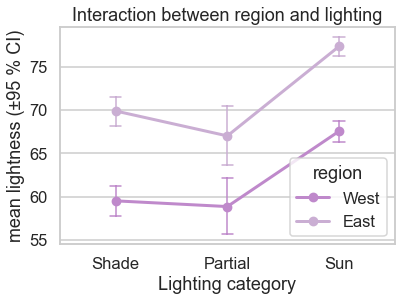

In [39]:
# make nice figure aesthetics
sns.set(style='whitegrid', context='talk', font_scale=1)

sns.pointplot(
    data=sub, x="lighting", y="lch_l", hue="region",
    #dodge=0.3, 
    capsize=.1,
    err_kws={'linewidth': 1.5},
    errorbar=('ci', 95),
    palette=['#bf89cb', '#caaed3'], 
    linewidth=3,
    #fliersize=4,
    #order=['West', 'East'],
    hue_order=['West', 'East'],
    order=["Shade","Partial","Sun"],
)
plt.ylabel("mean lightness (±95 % CI)")
plt.xlabel("Lighting category")
plt.title("Interaction between region and lighting")
plt.savefig('../figures/figures_current/components/figure_3e_L.pdf',dpi=300)
plt.show()

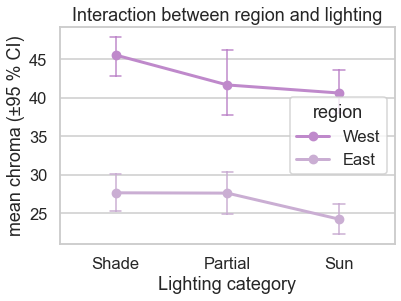

In [40]:
# make nice figure aesthetics
sns.set(style='whitegrid', context='talk', font_scale=1)

sns.pointplot(
    data=sub, x="lighting", y="lch_c", hue="region",
    #dodge=0.3, 
    capsize=.1,
    err_kws={'linewidth': 1.5},
    errorbar=('ci', 95),
    palette=['#bf89cb', '#caaed3'],
    linewidth=3,
    #fliersize=4,
    #order=['West', 'East'],
    hue_order=['West', 'East'],
    order=["Shade","Partial","Sun"],
)
plt.ylabel("mean chroma (±95 % CI)")
plt.xlabel("Lighting category")
plt.title("Interaction between region and lighting")
plt.savefig('../figures/figures_current/components/figure_3e_C.pdf',dpi=300)
plt.show()